# Лабораторная работа № 2
## Линейная и логистическая регрессия

**Сквозной кейс:** прогноз ценности веб-сессии и вероятности покупки.

Этот notebook содержит полностью исполняемый пример и блоки для самостоятельных заданий. Основной источник — [UCI Online Shoppers Purchasing Intention](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset).

## 1. Цель

1. Построить baseline линейной регрессии для `PageValues`.
2. Построить логистическую регрессию для `Revenue` без `PageValues`.
3. Выбрать порог по validation.
4. Реализовать batch gradient descent и проверить градиент.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression, SGDClassifier
from sklearn.metrics import *

print(sys.version)
print('pandas', pd.__version__, 'sklearn', sklearn.__version__)
RANDOM_STATE = 42

3.12.8 (main, Aug 11 2026, 02:20:20) [GCC 15.2.0]
pandas 2.2.3 sklearn 1.6.1


## 2. Данные

In [2]:
DATA_LOCAL = 'online_shoppers_intention.csv'
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv'
try:
    df = pd.read_csv(DATA_LOCAL)
except FileNotFoundError:
    df = pd.read_csv(DATA_URL)
print(df.shape)
display(df.head())
display(df['Revenue'].value_counts().rename('count'))
print('positive rate:', df['Revenue'].mean())
print('missing:', df.isna().sum().sum(), 'duplicates:', df.duplicated().sum())

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Revenue
False    10422
True      1908
Name: count, dtype: int64

positive rate: 0.15474452554744525
missing: 0 duplicates: 125


### Мини-аудит

Заполните: какие признаки известны до покупки? Может ли `PageValues` быть доступен в момент, когда требуется принять раннее решение?

In [3]:
num_all = ['Administrative','Administrative_Duration','Informational',
 'Informational_Duration','ProductRelated','ProductRelated_Duration',
 'BounceRates','ExitRates','PageValues','SpecialDay']
cat = ['Month','OperatingSystems','Browser','Region','TrafficType','VisitorType','Weekend']

display(df[num_all].describe().T)

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


## 3. Пример A: линейная регрессия для PageValues

In [4]:
reg_num = [c for c in num_all if c != 'PageValues']
Xr, yr = df[reg_num + cat], df['PageValues']
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    Xr, yr, test_size=.2, random_state=RANDOM_STATE)
prep_r = ColumnTransformer([
 ('num', Pipeline([('imp', SimpleImputer(strategy='median')),('sc', StandardScaler())]), reg_num),
 ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
])
models_r = {
 'dummy': Pipeline([('prep', prep_r),('model', DummyRegressor(strategy='mean'))]),
 'linear': Pipeline([('prep', prep_r),('model', LinearRegression())]),
 'ridge': Pipeline([('prep', prep_r),('model', Ridge(alpha=10.0))])
}
rows=[]
for name, model in models_r.items():
    model.fit(Xr_tr, yr_tr); pred=model.predict(Xr_te)
    rows.append({'model':name,'MAE':mean_absolute_error(yr_te,pred),
                 'RMSE':mean_squared_error(yr_te,pred)**.5,
                 'R2':r2_score(yr_te,pred)})
reg_results=pd.DataFrame(rows).sort_values('RMSE')
display(reg_results)

,model,MAE,RMSE,R2
2,ridge,9.228121,18.427038,0.049672
1,linear,9.245738,18.437496,0.048593
0,dummy,9.509796,18.904572,-0.000222


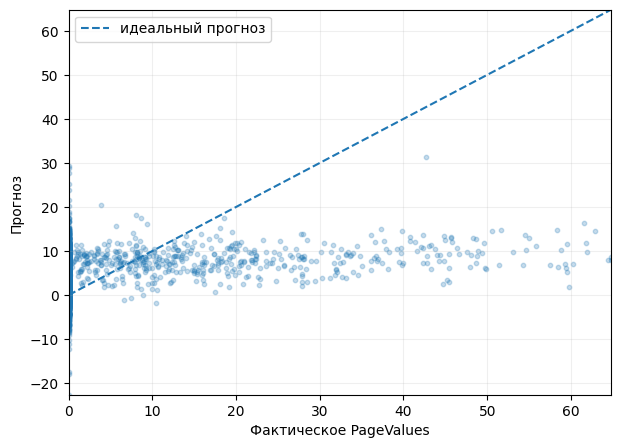

In [5]:
reg=models_r['linear']; pred=reg.predict(Xr_te)
lim=np.percentile(np.r_[yr_te.values,pred],99)
plt.figure(figsize=(7,5)); plt.scatter(yr_te,pred,s=10,alpha=.25)
plt.plot([0,lim],[0,lim],'--',label='идеальный прогноз')
plt.xlim(0,lim);plt.ylim(min(-2,pred.min()),lim)
plt.xlabel('Фактическое PageValues');plt.ylabel('Прогноз');plt.legend();plt.grid(alpha=.2);plt.show()

**Описание результата.** Линейная модель — слабый baseline: целевая переменная содержит много нулей и длинный хвост. Сравните `log1p`-target, Huber/Quantile и two-part approach.

## 4. Пример B: логистическая регрессия для Revenue

In [6]:
clf_num=[c for c in num_all if c!='PageValues']
X,y=df[clf_num+cat],df.Revenue.astype(int)
Xtr,Xtmp,ytr,ytmp=train_test_split(X,y,test_size=.4,stratify=y,random_state=RANDOM_STATE)
Xv,Xte,yv,yte=train_test_split(Xtmp,ytmp,test_size=.5,stratify=ytmp,random_state=RANDOM_STATE)
prep=ColumnTransformer([
 ('num',Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())]),clf_num),
 ('cat',OneHotEncoder(handle_unknown='ignore'),cat)
])
clf=Pipeline([('prep',prep),('model',LogisticRegression(max_iter=2000,C=1.0))])
clf.fit(Xtr,ytr)
pv=clf.predict_proba(Xv)[:,1]
precision,recall,thresholds=precision_recall_curve(yv,pv)
f1=2*precision*recall/(precision+recall+1e-15)
t_star=thresholds[np.argmax(f1[:-1])]
print('validation max-F1 threshold:',t_star)
pte=clf.predict_proba(Xte)[:,1]; pred=(pte>=t_star).astype(int)
print(confusion_matrix(yte,pred))
print({'accuracy':accuracy_score(yte,pred),'precision':precision_score(yte,pred),
 'recall':recall_score(yte,pred),'F1':f1_score(yte,pred),
 'ROC_AUC':roc_auc_score(yte,pte),'AP':average_precision_score(yte,pte),
 'log_loss':log_loss(yte,pte)})

validation max-F1 threshold: 0.21424357332371152
[[1589  495]
 [ 162  220]]
{'accuracy': 0.7335766423357665, 'precision': 0.3076923076923077, 'recall': 0.5759162303664922, 'F1': 0.4010938924339107, 'ROC_AUC': 0.7601333018460271, 'AP': 0.36945069962959576, 'log_loss': 0.3696313993736645}


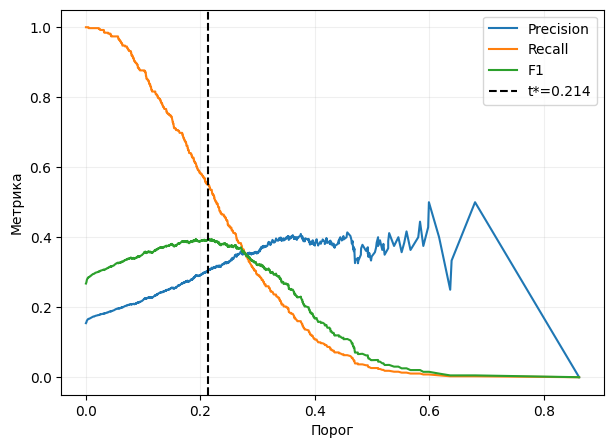

In [7]:
plt.figure(figsize=(7,5))
plt.plot(thresholds,precision[:-1],label='Precision')
plt.plot(thresholds,recall[:-1],label='Recall')
plt.plot(thresholds,f1[:-1],label='F1')
plt.axvline(t_star,ls='--',color='black',label=f't*={t_star:.3f}')
plt.xlabel('Порог');plt.ylabel('Метрика');plt.legend();plt.grid(alpha=.2);plt.show()

## 5. Utility-порог

In [8]:
def utility(y, pred, tp=8, fp=-1, fn=-3, tn=0):
    tn_n,fp_n,fn_n,tp_n=confusion_matrix(y,pred).ravel()
    return tp*tp_n+fp*fp_n+fn*fn_n+tn*tn_n

grid=np.linspace(.01,.99,99)
u=[utility(yv,(pv>=t).astype(int)) for t in grid]
t_u=grid[np.argmax(u)]
print('utility threshold:',t_u,'validation utility:',max(u))
print('test utility:',utility(yte,(pte>=t_u).astype(int)))

utility threshold: 0.06999999999999999 validation utility: 1414
test utility: 1388


## 6. Batch gradient descent с нуля

In [9]:
small_num=['Administrative_Duration','ProductRelated','ProductRelated_Duration',
           'BounceRates','ExitRates','SpecialDay']
Xs=df[small_num].astype(float).values; ys=y.values.astype(float)
Xa,Xb,ya,yb=train_test_split(Xs,ys,test_size=.2,stratify=ys,random_state=RANDOM_STATE)
mu,sd=Xa.mean(0),Xa.std(0);sd[sd==0]=1
Xa=np.c_[np.ones(len(Xa)),(Xa-mu)/sd]
Xb=np.c_[np.ones(len(Xb)),(Xb-mu)/sd]

def sigmoid(z):
    out=np.empty_like(z,dtype=float);pos=z>=0
    out[pos]=1/(1+np.exp(-z[pos]));ez=np.exp(z[~pos]);out[~pos]=ez/(1+ez)
    return out

def logloss_and_grad(X,y,w):
    z=X@w;return np.mean(np.logaddexp(0,z)-y*z),X.T@(sigmoid(z)-y)/len(y)

def fit_batch_gd(X,y,eta=.1,steps=300):
    w=np.zeros(X.shape[1]);history=[]
    for _ in range(steps):
        loss,grad=logloss_and_grad(X,y,w);history.append(loss);w-=eta*grad
    return w,history

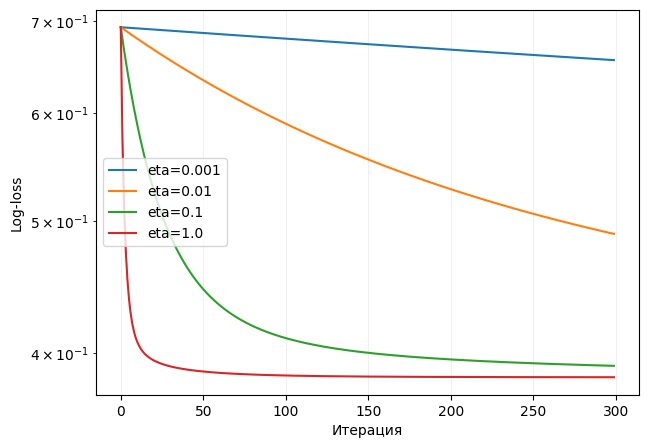

In [10]:
plt.figure(figsize=(7,5))
for eta in [.001,.01,.1,1.0]:
    w,h=fit_batch_gd(Xa,ya,eta=eta)
    plt.plot(h,label=f'eta={eta}')
plt.yscale('log');plt.xlabel('Итерация');plt.ylabel('Log-loss');plt.legend();plt.grid(alpha=.2);plt.show()

## 7. Gradient check

In [11]:
def gradient_check(X,y,w,eps=1e-6):
    _,g=logloss_and_grad(X,y,w);g_num=np.zeros_like(w)
    for j in range(len(w)):
        e=np.zeros_like(w);e[j]=eps
        lp,_=logloss_and_grad(X,y,w+e);lm,_=logloss_and_grad(X,y,w-e)
        g_num[j]=(lp-lm)/(2*eps)
    return np.linalg.norm(g-g_num)/(np.linalg.norm(g)+np.linalg.norm(g_num)+1e-15)
err=gradient_check(Xa[:200],ya[:200],np.zeros(Xa.shape[1]))
print('relative gradient error:',err)
assert err<1e-6

relative gradient error: 1.6901021866005045e-10


## 8. Самостоятельные задания

1. Добавьте Huber/Quantile или `log1p` для регрессии.
2. Сравните `LogisticRegression`, `class_weight='balanced'` и `SGDClassifier(loss='log_loss')`.
3. Реализуйте mini-batch и momentum.
4. Исследуйте `C`, L1/L2/Elastic Net.
5. Сравните max-F1 и utility-пороги.
6. Напишите выводы: числа, ограничения, следующая итерация.